# Customer Churn Analysis

This project analyzes customer churn behavior and builds a machine learning model to predict whether a customer is likely to churn. The goal is to identify key churn drivers and provide actionable business recommendations.

## Business Questions

- What customer groups have the highest churn rate?
- Which factors are strongly related to churn?
- Can we predict churn customers using machine learning?
- What actions can the business take to reduce churn?

# Import library package (thư viện)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA
import time
import warnings
warnings.filterwarnings('ignore')

# Read dataset and check overview

In [2]:
df = pd.read_csv("../data/Customer_cancellation.csv")

df.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Number of Referrals,Tenure in Months,Offer,Phone Service,...,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason,Churned,Stayed,Unnamed: 36,Unnamed: 37,Unnamed: 38
0,0021-IKXGC,Female,72.0,No,0.0,San Marcos,0.0,1.0,Offer E,Yes,...,7.77,79.87,Joined,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0023-HGHWL,Male,67.0,No,0.0,Morgan Hill,0.0,1.0,NaN,No,...,0.00,25.10,Churned,Competitor,Competitor made better offer,NaN,NaN,NaN,NaN,NaN
2,0032-PGELS,Female,37.0,Yes,1.0,Palomar Mountain,1.0,1.0,NaN,No,...,0.00,30.50,Churned,Attitude,Attitude of service provider,NaN,NaN,NaN,NaN,NaN
3,0082-LDZUE,Male,54.0,No,0.0,Calistoga,0.0,1.0,Offer E,Yes,...,42.95,87.25,Joined,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0107-WESLM,Male,32.0,No,0.0,West Point,0.0,1.0,Offer E,Yes,...,31.77,51.62,Churned,Attitude,Attitude of support person,NaN,NaN,NaN,NaN,NaN


In [3]:
df.tail(2)

,Customer ID,Gender,Age,Married,Number of Dependents,City,Number of Referrals,Tenure in Months,Offer,Phone Service,...,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason,Churned,Stayed,Unnamed: 36,Unnamed: 37,Unnamed: 38
7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7044,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.describe()

,Age,Number of Dependents,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Churned,Stayed,Unnamed: 36,Unnamed: 37,Unnamed: 38
count,7043.000000,7043.000000,7043.000000,7043.000000,6361.000000,5517.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,0.0,0.0,0.0,0.0,0.0
mean,46.509726,0.468692,1.951867,32.386767,25.420517,26.189958,63.596131,2280.381264,1.962182,6.860713,749.099262,3034.379056,NaN,NaN,NaN,NaN,NaN
std,16.750352,0.962802,3.001199,24.542061,14.200374,19.586585,31.204743,2266.220462,7.902614,25.104978,846.660055,2865.204542,NaN,NaN,NaN,NaN,NaN
min,19.000000,0.000000,0.000000,1.000000,1.010000,2.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000,NaN,NaN,NaN,NaN,NaN
25%,32.000000,0.000000,0.000000,9.000000,13.050000,13.000000,30.400000,400.150000,0.000000,0.000000,70.545000,605.610000,NaN,NaN,NaN,NaN,NaN
50%,46.000000,0.000000,0.000000,29.000000,25.690000,21.000000,70.050000,1394.550000,0.000000,0.000000,401.440000,2108.640000,NaN,NaN,NaN,NaN,NaN
75%,60.000000,0.000000,3.000000,55.000000,37.680000,30.000000,89.750000,3786.600000,0.000000,0.000000,1191.100000,4801.145000,NaN,NaN,NaN,NaN,NaN
max,80.000000,9.000000,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000,NaN,NaN,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7045 entries, 0 to 7044
Data columns (total 39 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   float64
 3   Married                            7043 non-null   object 
 4   Number of Dependents               7043 non-null   float64
 5   City                               7043 non-null   object 
 6   Number of Referrals                7043 non-null   float64
 7   Tenure in Months                   7043 non-null   float64
 8   Offer                              3166 non-null   object 
 9   Phone Service                      7043 non-null   object 
 10  Avg Monthly Long Distance Charges  6361 non-null   float64
 11  Multiple Lines                     6361 non-null   objec

In [6]:
df.isnull().sum()

Customer ID                             2
Gender                                  2
Age                                     2
Married                                 2
Number of Dependents                    2
City                                    2
Number of Referrals                     2
Tenure in Months                        2
Offer                                3879
Phone Service                           2
Avg Monthly Long Distance Charges     684
Multiple Lines                        684
Internet Service                        2
Internet Type                        1528
Avg Monthly GB Download              1528
Online Security                      1528
Online Backup                        1528
Device Protection Plan               1528
Premium Tech Support                 1528
Streaming TV                         1528
Streaming Movies                     1528
Streaming Music                      1528
Unlimited Data                       1528
Contract                          

In [7]:
df.columns

Index(['Customer ID', 'Gender', 'Age', 'Married', 'Number of Dependents',
       'City', 'Number of Referrals', 'Tenure in Months', 'Offer',
       'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Payment Method',
       'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Customer Status', 'Churn Category', 'Churn Reason',
       'Churned', 'Stayed', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38'],
      dtype='object')

In [8]:
df = df.loc[:, ~df.columns.str.contains("Unnamed")]

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7045 entries, 0 to 7044
Data columns (total 36 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   float64
 3   Married                            7043 non-null   object 
 4   Number of Dependents               7043 non-null   float64
 5   City                               7043 non-null   object 
 6   Number of Referrals                7043 non-null   float64
 7   Tenure in Months                   7043 non-null   float64
 8   Offer                              3166 non-null   object 
 9   Phone Service                      7043 non-null   object 
 10  Avg Monthly Long Distance Charges  6361 non-null   float64
 11  Multiple Lines                     6361 non-null   objec

In [10]:
df["Churned"].value_counts()

Series([], Name: count, dtype: int64)

# EDA

## Target Distribution

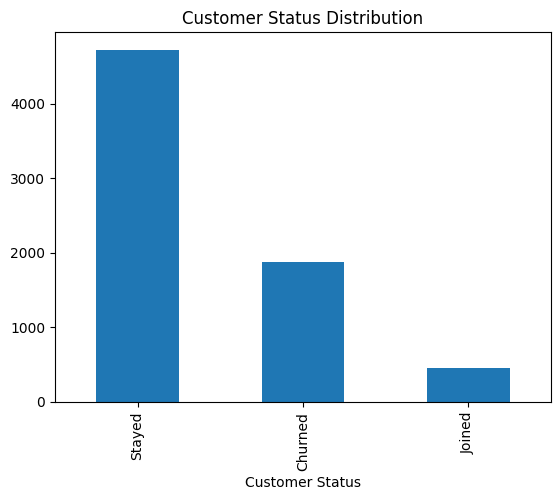

In [11]:
df["Customer Status"].value_counts().plot(kind="bar")
plt.title("Customer Status Distribution")
plt.savefig("../images/churn_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

Biểu đồ cho thấy số lượng khách hàng ở từng trạng thái (Stayed, Joined, Churned).
Nhóm "Stayed" chiếm tỷ lệ lớn nhất, trong khi "Churned" chiếm tỷ lệ thấp hơn, cho thấy dữ liệu có sự mất cân bằng nhẹ giữa các lớp.

## Missing Value Analysis

In [12]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

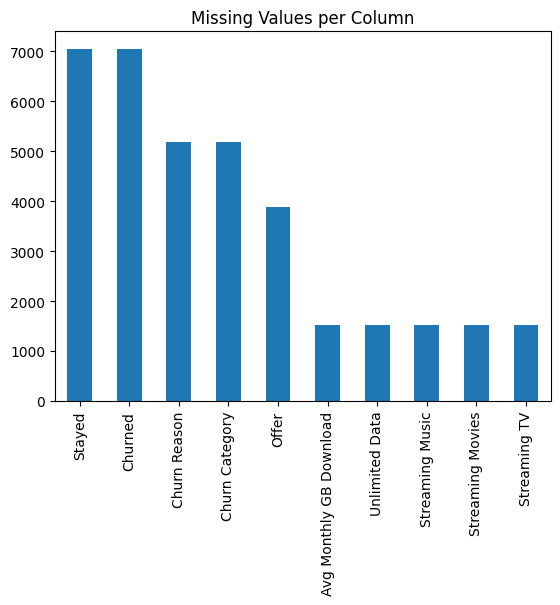

In [13]:
if len(missing) > 0:
    missing.head(10).plot(kind="bar")
    plt.title("Missing Values per Column")
    plt.show()
else:
    print("No missing values in dataset")

## Outlier Analysis

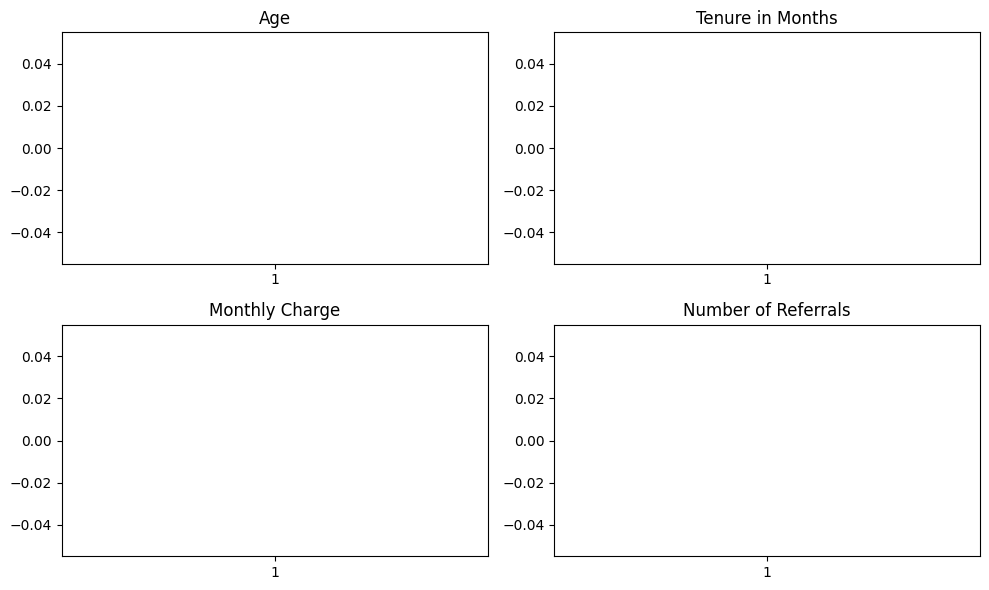

In [14]:
import matplotlib.pyplot as plt

num_cols = ["Age", "Tenure in Months", "Monthly Charge", "Number of Referrals"]

plt.figure(figsize=(10,6))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    plt.boxplot(df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Boxplot cho thấy một số biến có sự xuất hiện của giá trị ngoại lai (outliers).

Cụ thể, biến "Number of Referrals" có nhiều điểm nằm ngoài khoảng phân bố chính, cho thấy sự tồn tại của các giá trị bất thường.

Trong khi đó, các biến như "Age" và "Tenure in Months" có phân bố tương đối ổn định và ít outlier hơn.

Các outliers này có thể ảnh hưởng đến mô hình, tuy nhiên sẽ được cân nhắc xử lý hoặc giữ lại tùy theo mức độ ảnh hưởng.

## Relationship between Features and Customer Status

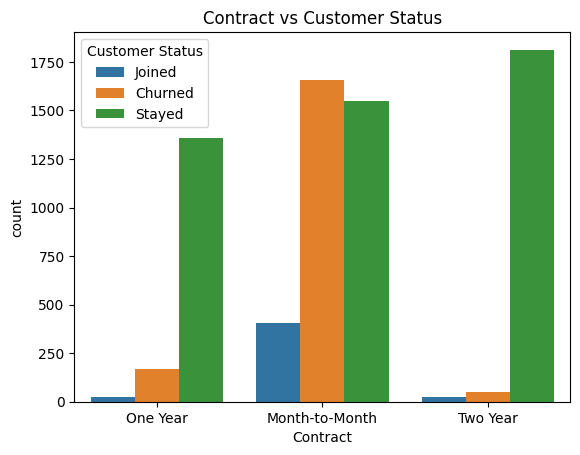

In [15]:
sns.countplot(x="Contract", hue="Customer Status", data=df)
plt.title("Contract vs Customer Status")
plt.savefig("../images/contract_vs_churn.png", dpi=300, bbox_inches="tight")
plt.show()

Biểu đồ cho thấy khách hàng sử dụng hợp đồng ngắn hạn (Month-to-Month) có tỷ lệ churn cao hơn đáng kể so với các hợp đồng dài hạn.

Ngược lại, khách hàng sử dụng hợp đồng 1 năm hoặc 2 năm có xu hướng duy trì dịch vụ nhiều hơn.

Điều này cho thấy loại hợp đồng là một yếu tố quan trọng ảnh hưởng đến hành vi churn.

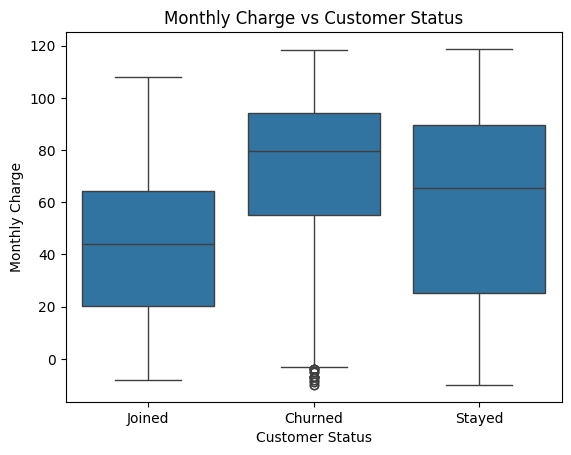

In [16]:
sns.boxplot(x="Customer Status", y="Monthly Charge", data=df)
plt.title("Monthly Charge vs Customer Status")
plt.savefig("../images/monthly_charge_vs_churn.png", dpi=300, bbox_inches="tight")
plt.show()

Khách hàng thuộc nhóm churn có mức phí hàng tháng trung bình cao hơn so với các nhóm còn lại.

Điều này cho thấy chi phí dịch vụ có thể là nguyên nhân khiến khách hàng rời bỏ dịch vụ.

Ngược lại, khách hàng có mức phí thấp hơn có xu hướng duy trì dịch vụ lâu dài hơn.

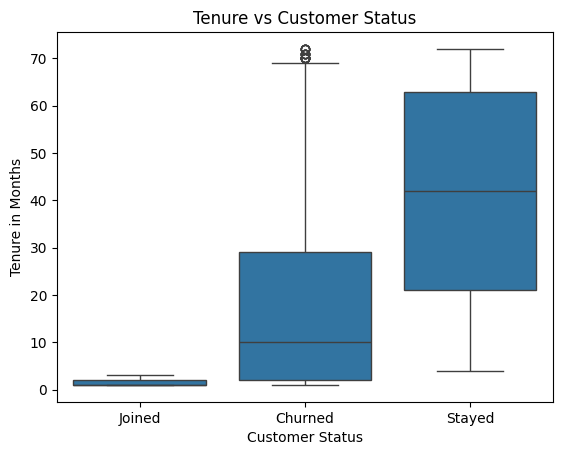

In [17]:
sns.boxplot(x="Customer Status", y="Tenure in Months", data=df)
plt.title("Tenure vs Customer Status")
plt.show()

Khách hàng có thời gian sử dụng dịch vụ ngắn (tenure thấp) có xu hướng churn nhiều hơn.

Trong khi đó, những khách hàng gắn bó lâu dài thường có tỷ lệ churn thấp.

Điều này cho thấy mức độ gắn bó với dịch vụ là yếu tố quan trọng ảnh hưởng đến hành vi churn.

#### => Kết luận: 
Trong quá trình EDA, không cần thiết phải phân tích tất cả các biến với biến mục tiêu.

Việc lựa chọn một số biến tiêu biểu giúp tập trung vào những đặc trưng quan trọng và tránh gây rối thông tin.

Ngoài ra, việc trực quan hóa quá nhiều biểu đồ có thể làm giảm tính rõ ràng và khó rút ra insight chính.

# Data cleaning

## Remove duplicates

In [18]:
df.duplicated().any()

np.True_

In [19]:
df.duplicated().sum()

np.int64(1)

In [20]:
df[df.duplicated()]

,Customer ID,Gender,Age,Married,Number of Dependents,City,Number of Referrals,Tenure in Months,Offer,Phone Service,...,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason,Churned,Stayed
7044,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
df = df.drop_duplicates()

In [22]:
df.duplicated().any()

np.False_

In [23]:
# Export cleaned dataset
df.to_csv("cleaned_churn_data.csv", index=False)

## Clean data (Xoá cột không cần)

In [24]:
# Xóa cột không cần
df = df.drop([
    "Customer ID",
    "Churn Reason",
    "Churn Category",
    "Stayed",
    "Churned"
], axis=1)


In [25]:
# Xóa cột rác nếu có
df = df.loc[:, ~df.columns.str.contains("Unnamed")]

## Xoá cột missing value nhiều

In [26]:
df = df.drop("Offer", axis=1)

In [27]:
df.isnull().sum()

Gender                                  1
Age                                     1
Married                                 1
Number of Dependents                    1
City                                    1
Number of Referrals                     1
Tenure in Months                        1
Phone Service                           1
Avg Monthly Long Distance Charges     683
Multiple Lines                        683
Internet Service                        1
Internet Type                        1527
Avg Monthly GB Download              1527
Online Security                      1527
Online Backup                        1527
Device Protection Plan               1527
Premium Tech Support                 1527
Streaming TV                         1527
Streaming Movies                     1527
Streaming Music                      1527
Unlimited Data                       1527
Contract                                1
Payment Method                          1
Monthly Charge                    

## Handel missing value

In [28]:
# Tách cột số và cột chữ
num_cols = df.select_dtypes(include=["float64", "int64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns.drop("Customer Status")

In [29]:
# Fill cột số bằng median
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill cột chữ bằng mode
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [30]:
df = df.dropna(subset=["Customer Status"])

In [31]:
df.isnull().sum()

Gender                               0
Age                                  0
Married                              0
Number of Dependents                 0
City                                 0
Number of Referrals                  0
Tenure in Months                     0
Phone Service                        0
Avg Monthly Long Distance Charges    0
Multiple Lines                       0
Internet Service                     0
Internet Type                        0
Avg Monthly GB Download              0
Online Security                      0
Online Backup                        0
Device Protection Plan               0
Premium Tech Support                 0
Streaming TV                         0
Streaming Movies                     0
Streaming Music                      0
Unlimited Data                       0
Contract                             0
Payment Method                       0
Monthly Charge                       0
Total Charges                        0
Total Refunds            

In [32]:
df["Customer Status"].value_counts()

Customer Status
Stayed     4720
Churned    1869
Joined      454
Name: count, dtype: int64

In [33]:
df.head(5)

,Gender,Age,Married,Number of Dependents,City,Number of Referrals,Tenure in Months,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,...,Unlimited Data,Contract,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status
0,Female,72.0,No,0.0,San Marcos,0.0,1.0,Yes,7.77,Yes,...,Yes,One Year,Bank Withdrawal,72.10,72.10,0.0,0.0,7.77,79.87,Joined
1,Male,67.0,No,0.0,Morgan Hill,0.0,1.0,No,25.69,No,...,Yes,Month-to-Month,Bank Withdrawal,25.10,25.10,0.0,0.0,0.00,25.10,Churned
2,Female,37.0,Yes,1.0,Palomar Mountain,1.0,1.0,No,25.69,No,...,Yes,Month-to-Month,Bank Withdrawal,30.50,30.50,0.0,0.0,0.00,30.50,Churned
3,Male,54.0,No,0.0,Calistoga,0.0,1.0,Yes,42.95,No,...,Yes,Month-to-Month,Credit Card,44.30,44.30,0.0,0.0,42.95,87.25,Joined
4,Male,32.0,No,0.0,West Point,0.0,1.0,Yes,31.77,No,...,Yes,Month-to-Month,Bank Withdrawal,19.85,19.85,0.0,0.0,31.77,51.62,Churned


# Preprocessing

## Encoding

In [34]:
df["Churned"] = df["Customer Status"].map({
    "Stayed": 0,
    "Joined": 0,
    "Churned": 1
})

In [35]:
df = df.drop("Customer Status", axis=1)

In [36]:
df = pd.get_dummies(df, drop_first=True).astype(int)

In [37]:
df["Churned"].value_counts()

Churned
0    5174
1    1869
Name: count, dtype: int64

In [38]:
df.head()

,Age,Number of Dependents,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,...,Device Protection Plan_Yes,Premium Tech Support_Yes,Streaming TV_Yes,Streaming Movies_Yes,Streaming Music_Yes,Unlimited Data_Yes,Contract_One Year,Contract_Two Year,Payment Method_Credit Card,Payment Method_Mailed Check
0,72,0,0,1,7,22,72,72,0,0,...,0,0,0,0,0,1,1,0,0,0
1,67,0,0,1,25,9,25,25,0,0,...,0,0,0,0,0,1,0,0,0,0
2,37,1,1,1,25,19,30,30,0,0,...,0,0,0,0,0,1,0,0,0,0
3,54,0,0,1,42,9,44,44,0,0,...,0,0,0,0,0,1,0,0,1,0
4,32,0,0,1,31,21,19,19,0,0,...,0,0,0,0,0,1,0,0,0,0


## Train test split

In [39]:
X = df.drop("Churned", axis=1)
y = df["Churned"]

In [40]:
print(X.shape)
print(y.shape)
print(y.value_counts())

(7043, 1136)
(7043,)
Churned
0    5174
1    1869
Name: count, dtype: int64


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [42]:
print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(5634, 1136)
(1409, 1136)
Churned
0    4139
1    1495
Name: count, dtype: int64
Churned
0    1035
1     374
Name: count, dtype: int64


# Train model

### TRAIN LOGISTIC REGRESSION

In [43]:
from sklearn.linear_model import LogisticRegression

In [44]:
log_model = LogisticRegression()

In [45]:
log_model.fit(X_train,y_train)

LogisticRegression()

In [46]:
y_pred_log = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_log))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

Accuracy: 0.801277501774308

Confusion Matrix:
[[954  81]
 [199 175]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1035
           1       0.68      0.47      0.56       374

    accuracy                           0.80      1409
   macro avg       0.76      0.69      0.71      1409
weighted avg       0.79      0.80      0.79      1409



Class 0 (không churn):

Precision: 0.83

Recall: 0.92

=> Model dự đoán khách ở lại rất tốt

Class 1 (churn – quan trọng nhất):

Precision: 0.68

Recall: 0.47 

F1-score: 0.56

=> Nghĩa là:

Model chỉ bắt được 47% khách sắp rời đi
→ bỏ sót hơn 50% khách churn


Accuracy không quan trọng nhất

Recall (churn) mới quan trọng

→ vì: bỏ sót khách sắp rời đi = mất tiền

=> Mô hình Logistic Regression đạt độ chính xác khoảng 80%, cho thấy khả năng dự đoán tổng thể ở mức khá. Tuy nhiên, mô hình có recall thấp đối với nhóm khách hàng churn (0.47), nghĩa là bỏ sót một lượng lớn khách có nguy cơ rời bỏ. Điều này làm giảm giá trị ứng dụng thực tế của mô hình trong bài toán giữ chân khách hàng.

### TRAIN RANDOM FOREST

In [47]:
from sklearn.ensemble import RandomForestClassifier

In [48]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [49]:
y_pred_rf = rf_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8353442157558553

Confusion Matrix:
[[977  58]
 [174 200]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.94      0.89      1035
           1       0.78      0.53      0.63       374

    accuracy                           0.84      1409
   macro avg       0.81      0.74      0.76      1409
weighted avg       0.83      0.84      0.82      1409



So với Logistic Regression, mô hình Random Forest cho kết quả tốt hơn với độ chính xác cao hơn (0.84 so với 0.80). Đồng thời, recall của nhóm khách hàng churn được cải thiện (từ 0.47 lên 0.53), cho thấy mô hình đã phát hiện được nhiều khách hàng có nguy cơ rời bỏ hơn. Tuy nhiên, mô hình vẫn còn bỏ sót một lượng đáng kể khách churn, do đó cần tiếp tục tối ưu.

## Chọn model tốt nhất

In [50]:
models = [
    ("KNN", KNeighborsClassifier()),
    ("DecisionTree", DecisionTreeClassifier(random_state=42)),
    ("RandomForest", RandomForestClassifier(random_state=42, n_jobs=-1)),
    ("SVM", SVC(class_weight="balanced")),
    ("AdaBoost", AdaBoostClassifier(random_state=42)),
    ("GradientBoost", GradientBoostingClassifier(random_state=42))
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []
times = []
names = []

for name, clf in models:
    start = time.time()

    score = cross_val_score(
        clf,
        X_train,
        y_train,
        cv=cv,
        scoring="f1"
    ).mean()

    end = time.time()

    names.append(name)
    scores.append(score)
    times.append(end - start)

result_df = pd.DataFrame({
    "Model": names,
    "CV_F1": scores,
    "Time(s)": times
}).sort_values("CV_F1", ascending=False)

result_df

,Model,CV_F1,Time(s)
5,GradientBoost,0.694026,11.914968
4,AdaBoost,0.678269,3.647023
2,RandomForest,0.641012,0.821164
1,DecisionTree,0.632218,0.588766
3,SVM,0.500777,28.945962
0,KNN,0.455968,0.893761


Kết quả so sánh các mô hình cho thấy Gradient Boosting đạt F1-score cao nhất (0.694), vượt trội so với các mô hình còn lại.

Các mô hình ensemble như Gradient Boosting và AdaBoost cho hiệu suất tốt hơn do khả năng kết hợp nhiều weak learners để học các pattern phức tạp trong dữ liệu.

Random Forest có kết quả thấp hơn, trong khi các mô hình như SVM và KNN cho hiệu suất kém hơn, có thể do dữ liệu có số chiều lớn (1136 features), gây khó khăn trong việc học hiệu quả.

Do đó, Gradient Boosting được lựa chọn là mô hình tốt nhất cho bài toán dự đoán churn.

## Train lại model tốt nhất

In [51]:
from sklearn.ensemble import GradientBoostingClassifier

In [52]:
best_model = GradientBoostingClassifier(random_state=42)

In [53]:
best_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [54]:
y_pred_best = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

Accuracy: 0.8523775727466288

Confusion Matrix:
[[969  66]
 [142 232]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.94      0.90      1035
           1       0.78      0.62      0.69       374

    accuracy                           0.85      1409
   macro avg       0.83      0.78      0.80      1409
weighted avg       0.85      0.85      0.85      1409



Sau khi so sánh nhiều mô hình, Gradient Boosting cho kết quả tốt nhất với độ chính xác khoảng 85% và đặc biệt là recall của nhóm khách hàng churn đạt 0.62, cao hơn đáng kể so với các mô hình trước đó. Điều này cho thấy mô hình có khả năng phát hiện khách hàng có nguy cơ rời bỏ tốt hơn, phù hợp với mục tiêu của bài toán.

<Figure size 600x500 with 0 Axes>

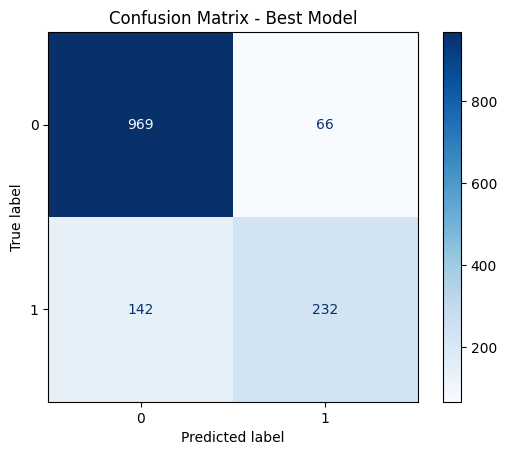

In [55]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best,
    cmap="Blues"
)

plt.title("Confusion Matrix - Best Model")
plt.savefig("../images/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

## Phân tích feature importance

In [56]:
importance = best_model.feature_importances_

feat_imp = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

feat_imp.head(20)

,Feature,Importance
2,Number of Referrals,0.167878
1133,Contract_Two Year,0.157078
3,Tenure in Months,0.125438
6,Monthly Charge,0.107678
1132,Contract_One Year,0.104373
0,Age,0.071101
1,Number of Dependents,0.052073
1134,Payment Method_Credit Card,0.043732
867,City_San Diego,0.032465
1121,Internet Service_Yes,0.018178


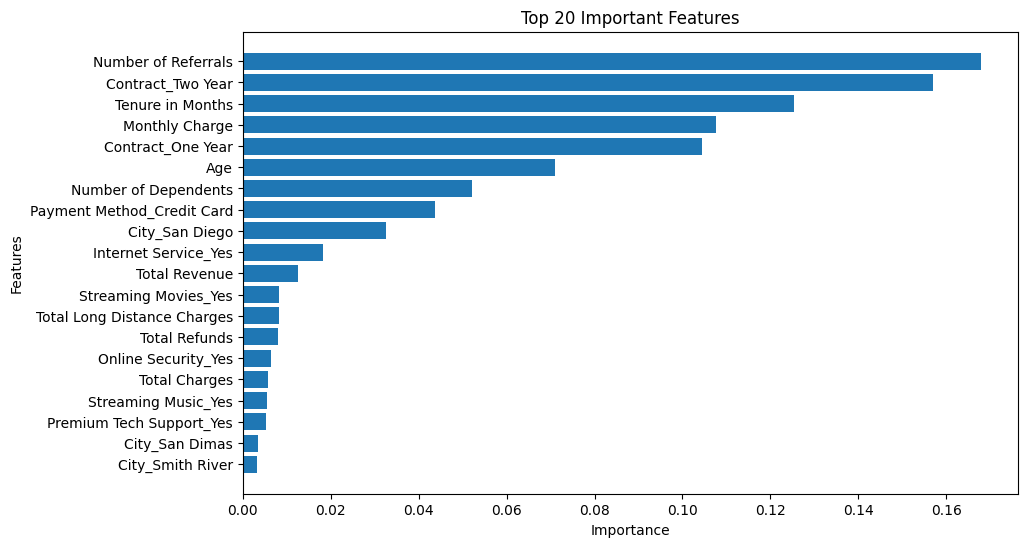

In [57]:
# Vẽ biểu đồ top feature
top_features = feat_imp.head(20)

plt.figure(figsize=(10,6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Important Features")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.savefig("../images/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

In [58]:
# lấy Top 20 feature quan trọng nhất
top_n = 20
selected_features = feat_imp.head(top_n)["Feature"].tolist()
# Giảm kích thước dữ liệu còn 20 features
X_train_top = X_train[selected_features]
X_test_top = X_test[selected_features]

print(X_train_top.shape)
print(X_test_top.shape)

(5634, 20)
(1409, 20)


## Train model with top 20 features

In [59]:
best_model_top = GradientBoostingClassifier(random_state=42)
best_model_top.fit(X_train_top, y_train)

y_pred_top = best_model_top.predict(X_test_top)

print("Accuracy:", accuracy_score(y_test, y_pred_top))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_top))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_top))

Accuracy: 0.8552164655784245

Confusion Matrix:
[[968  67]
 [137 237]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.90      1035
           1       0.78      0.63      0.70       374

    accuracy                           0.86      1409
   macro avg       0.83      0.78      0.80      1409
weighted avg       0.85      0.86      0.85      1409



## Compare Full vs Reduced Features

In [60]:
from sklearn.metrics import precision_score, recall_score, f1_score

comparison_df = pd.DataFrame({
    "Model": ["GradientBoost_Full", "GradientBoost_Top20"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_best),
        accuracy_score(y_test, y_pred_top)
    ],
    "Precision": [
        precision_score(y_test, y_pred_best),
        precision_score(y_test, y_pred_top)
    ],
    "Recall": [
        recall_score(y_test, y_pred_best),
        recall_score(y_test, y_pred_top)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_best),
        f1_score(y_test, y_pred_top)
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1-score
0,GradientBoost_Full,0.852378,0.778523,0.620321,0.690476
1,GradientBoost_Top20,0.855216,0.779605,0.633690,0.699115


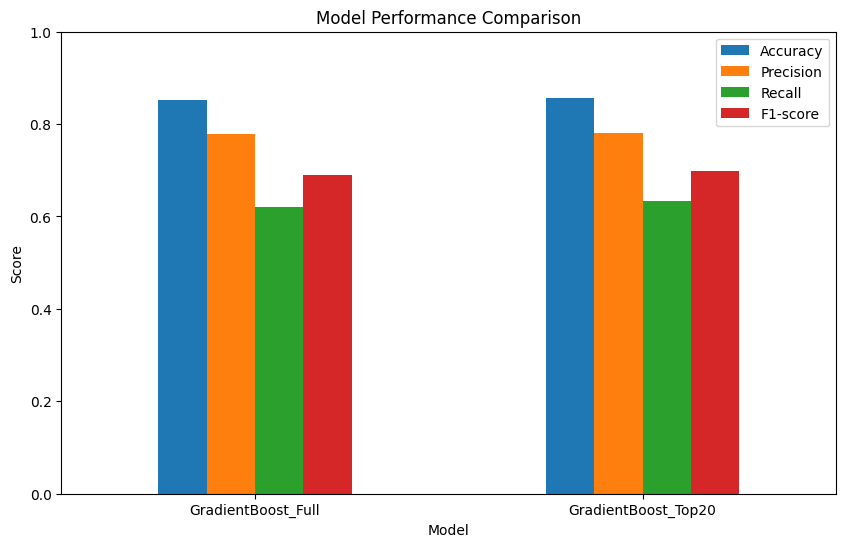

In [61]:
comparison_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)

plt.savefig("../images/model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# Lưu model

In [62]:
import pickle

with open("../model/model.pkl", "wb") as f:
    pickle.dump(best_model_top, f)

In [63]:
with open("../model/features.pkl", "wb") as f:
    pickle.dump(selected_features, f)